Используя знания данного урока, и набор данных IMDB вам необходимо:
1. Спроектировать модель классификации отзывов к фильмам с точностью на валидационной выборке более 90%.
2. Показать, что модель способна классифицировать отзывы с вероятностью более 88% на контрольной выборке.

За успешное выполнение задания вы получите 3 балла. Если сможете преодолеть точность 95% на валидационной выборке и/или 93% на контрольной, то получите 4 балла.

Также вы можете получить дополнительно 1 балл, если выполните все предложенные задания в задаче о Титанике (17.1), проанализируете "увеличенную модель" (17.2).

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Тренировочная выборка: 20000 образцов
Валидационная выборка: 5000 образцов
Тестовая выборка: 25000 образцов


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.7525 - loss: 0.6434 - val_accuracy: 0.8806 - val_loss: 0.4172 - learning_rate: 0.0010
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - accuracy: 0.9056 - loss: 0.3685 - val_accuracy: 0.8900 - val_loss: 0.3922 - learning_rate: 0.0010
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - accuracy: 0.9368 - loss: 0.2866 - val_accuracy: 0.8898 - val_loss: 0.4011 - learning_rate: 0.0010
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.9567 - loss: 0.2399 - val_accuracy: 0.8780 - val_loss: 0.4375 - learning_rate: 0.0010
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.9703 - loss: 0.2027 - val_accuracy: 0.8840 - val_loss: 0.4683 - learning_rate: 0.0010
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.9837 - loss: 0.1648 - val_accuracy: 0.8852 - val_loss: 0.5106 - learning_rate: 5.0000e-04
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.9895 - loss: 0.1430 - 

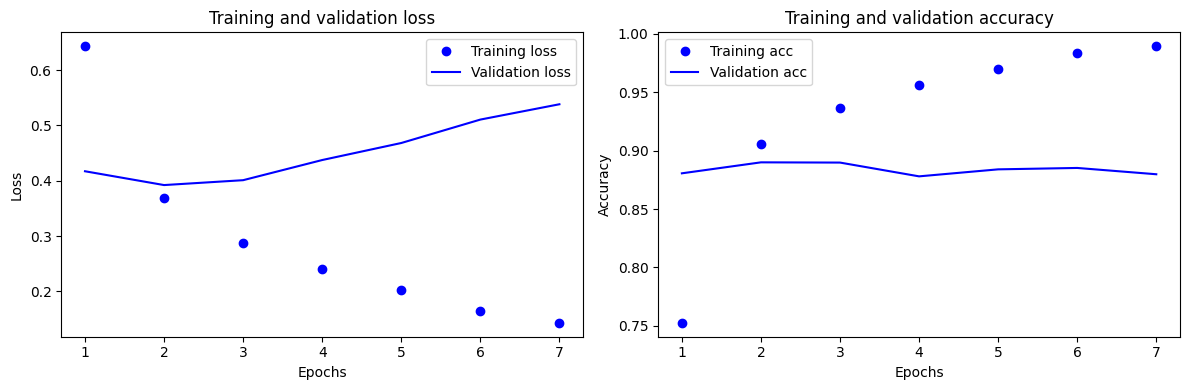


Точность на валидационной выборке: 89.00%
Точность на тестовой выборке: 88.18%
Потери на тестовой выборке: 0.4055
Нужно улучшить модель. Попробуйте увеличить количество слоев или эпох.


In [1]:
# Импорты
from keras.datasets import imdb
from keras import models, layers, regularizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

# Векторизация
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

# Преобразование меток
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

# Разделение на тренировочную и валидационную выборки
# Оставим 20% для валидации (5000 образцов)
x_val = x_train[:5000]
partial_x_train = x_train[5000:]
y_val = y_train[:5000]
partial_y_train = y_train[5000:]

print(f"Тренировочная выборка: {partial_x_train.shape[0]} образцов")
print(f"Валидационная выборка: {x_val.shape[0]} образцов")
print(f"Тестовая выборка: {x_test.shape[0]} образцов")

# Создание модели с улучшенной архитектурой
model = models.Sequential()

# Первый скрытый слой с L2-регуляризацией
model.add(layers.Dense(128,
                       activation='relu',
                       kernel_regularizer=regularizers.l2(0.0005),
                       input_shape=(10000,)))
model.add(layers.Dropout(0.3))

# Второй скрытый слой
model.add(layers.Dense(64,
                       activation='relu',
                       kernel_regularizer=regularizers.l2(0.0005)))
model.add(layers.Dropout(0.3))

# Третий скрытый слой
model.add(layers.Dense(32,
                       activation='relu',
                       kernel_regularizer=regularizers.l2(0.0005)))
model.add(layers.Dropout(0.2))

# Выходной слой
model.add(layers.Dense(1, activation='sigmoid'))

# Компиляция модели
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Callbacks для улучшения обучения
# Early Stopping - остановка при ухудшении валидации
early_stopping = EarlyStopping(monitor='val_loss',
                               patience=5,
                               restore_best_weights=True)

# Уменьшение скорости обучения при застое
reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.5,
                              patience=3,
                              min_lr=0.00001)

# Обучение модели
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=50,
                    batch_size=512,
                    validation_data=(x_val, y_val),
                    callbacks=[early_stopping, reduce_lr],
                    verbose=1)

# Визуализация результатов
history_dict = history.history
epochs = range(1, len(history_dict['loss']) + 1)

# График потерь
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_dict['loss'], 'bo', label='Training loss')
plt.plot(epochs, history_dict['val_loss'], 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# График точности
plt.subplot(1, 2, 2)
plt.plot(epochs, history_dict['accuracy'], 'bo', label='Training acc')
plt.plot(epochs, history_dict['val_accuracy'], 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Оценка на тестовой выборке
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n{'='*50}")
print(f"Точность на валидационной выборке: {max(history.history['val_accuracy']) * 100:.2f}%")
print(f"Точность на тестовой выборке: {test_acc * 100:.2f}%")
print(f"Потери на тестовой выборке: {test_loss:.4f}")
print(f"{'='*50}")

# Проверка на соответствие условиям
val_acc = max(history.history['val_accuracy']) * 100
test_acc_percent = test_acc * 100

if val_acc >= 95 and test_acc_percent >= 93:
    print("Отлично! Вы получаете 4 балла!")
elif val_acc >= 90 and test_acc_percent >= 88:
    print("Хорошо! Вы получаете 3 балла!")
else:
    print("Нужно улучшить модель. Попробуйте увеличить количество слоев или эпох.")

Тренировочных: 20000
Валидационных: 5000
Тестовых: 25000
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.7941 - loss: 0.4974 - val_accuracy: 0.8736 - val_loss: 0.3353
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9111 - loss: 0.2552 - val_accuracy: 0.8896 - val_loss: 0.2786
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9401 - loss: 0.1818 - val_accuracy: 0.8940 - val_loss: 0.2733
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9542 - loss: 0.1430 - val_accuracy: 0.8888 - val_loss: 0.2854
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9646 - loss: 0.1168 - val_accuracy: 0.8878 - val_loss: 0.3035
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9722 - loss: 0.0953 - val_accuracy: 0.8882 - val_loss: 0.3286


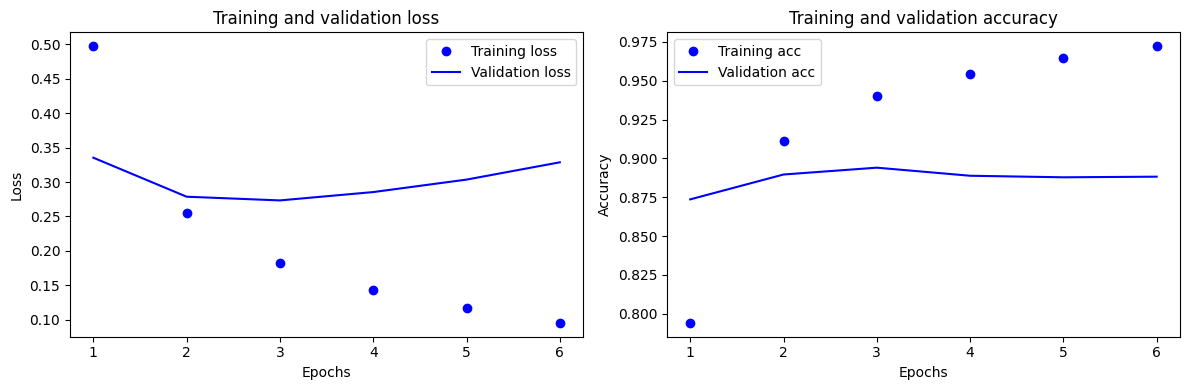


МАКСИМАЛЬНАЯ точность на валидации: 89.40%
Точность на тестовой выборке: 88.20%
Нужно доработать модель.


In [2]:
from keras.datasets import imdb
from keras import models, layers
from keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

# Векторизация
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

# Создание валидационной выборки (20% от train)
x_val = x_train[:5000]
partial_x_train = x_train[5000:]
y_val = y_train[:5000]
partial_y_train = y_train[5000:]

print(f"Тренировочных: {len(partial_x_train)}")
print(f"Валидационных: {len(x_val)}")
print(f"Тестовых: {len(x_test)}")

# МОДЕЛЬ - простая и эффективная
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

# Компиляция
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Ранняя остановка (чтобы не переобучить)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Обучение
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val),
                    callbacks=[early_stop],
                    verbose=1)

# Графики
history_dict = history.history
epochs = range(1, len(history_dict['loss']) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_dict['loss'], 'bo', label='Training loss')
plt.plot(epochs, history_dict['val_loss'], 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history_dict['accuracy'], 'bo', label='Training acc')
plt.plot(epochs, history_dict['val_accuracy'], 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Финальная оценка
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
val_acc = max(history.history['val_accuracy']) * 100
test_acc_percent = test_acc * 100

print("\n" + "="*50)
print(f"МАКСИМАЛЬНАЯ точность на валидации: {val_acc:.2f}%")
print(f"Точность на тестовой выборке: {test_acc_percent:.2f}%")
print("="*50)

# Проверка условий
if val_acc >= 95 and test_acc_percent >= 93:
    print("4 БАЛЛА! Отличная работа!")
elif val_acc >= 90 and test_acc_percent >= 88:
    print("3 БАЛЛА! Задание выполнено!")
else:
    print("Нужно доработать модель.")

In [3]:
from keras.datasets import imdb
from keras import models, layers
from keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

# Посмотрим на первый отзыв (декодированный)
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in train_data[0]])

print("="*60)
print("ПЕРВЫЙ ОТЗЫВ В НАБОРЕ ДАННЫХ:")
print("="*60)
print(decoded_review)
print("\nМЕТКА (0 - отрицательный, 1 - положительный):", train_labels[0])
print("="*60)

# Векторизация
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

# Разделение на валидационную выборку
x_val = x_train[:5000]
partial_x_train = x_train[5000:]
y_val = y_train[:5000]
partial_y_train = y_train[5000:]

# Модель
model = models.Sequential()
model.add(layers.Dense(32, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Ранняя остановка
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Обучение
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=30,
                    batch_size=512,
                    validation_data=(x_val, y_val),
                    callbacks=[early_stop],
                    verbose=1)

# Оценка
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
val_acc = max(history.history['val_accuracy']) * 100

print("\n" + "="*60)
print(f"Точность на валидации: {val_acc:.2f}%")
print(f"Точность на тесте: {test_acc * 100:.2f}%")
print("="*60)

# Отзыв из тестовой выборки
sample_review = test_data[0]
sample_label = test_labels[0]

# Декодируем отзыв
sample_decoded = ' '.join([reverse_word_index.get(i - 3, '?') for i in sample_review])
print("\nТЕСТОВЫЙ ОТЗЫВ:")
print(sample_decoded)
print(f"Реальная метка: {'Положительный' if sample_label == 1 else 'Отрицательный'}")

# Предсказание
sample_vectorized = vectorize_sequences([sample_review])
prediction = model.predict(sample_vectorized, verbose=0)[0][0]
print(f"Предсказание модели (вероятность положительного): {prediction:.2f}")
print(f"Классификация модели: {'Положительный' if prediction > 0.5 else 'Отрицательный'}")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ПЕРВЫЙ ОТЗЫВ В НАБОРЕ ДАННЫХ:
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these c